## Initial Review

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime as dt
import os 
import plotly.express as px

In [50]:
fin_df = pd.read_excel(r'D:\Workspace\Projects\AI_ML\behavioural-finance-analyser\data\raw\personal finance data.xlsx')
display(fin_df.head())

,Date / Time,Mode,Category,Sub category,Income/Expense,Debit/Credit
0,2021-01-01 21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0
1,2021-01-01 21:46:00,CUB - online payment,Food,Snacks,Expense,85.0
2,2021-01-03 18:21:00,CUB - online payment,Other,From dad,Income,500.0
3,2021-01-03 18:22:00,CUB - online payment,Household,Stuffs,Expense,6667.0
4,2021-01-03 18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0


In [51]:
fin_df.columns

Index(['Date / Time', 'Mode', 'Category', 'Sub category', 'Income/Expense',
       'Debit/Credit'],
      dtype='str')

In [52]:
print(max(fin_df['Date / Time']), min(fin_df['Date / Time']))

# the darta is for 1 year of timeline.


2021-12-30 14:10:00 2021-01-01 21:45:00


In [53]:
fin_df.dtypes

Date / Time       datetime64[us]
Mode                         str
Category                     str
Sub category                 str
Income/Expense               str
Debit/Credit             float64
dtype: object

In [54]:
import datetime as dt

fin_df['Date'] = fin_df['Date / Time'].dt.date
fin_df['Time'] = fin_df['Date / Time'].dt.time

# delete the column and shift date and time at the start

fin_df = fin_df.drop(columns=['Date / Time'])

cols = ['Date', 'Time'] + [col for col in fin_df.columns if col not in ['Date', 'Time']]
fin_df = fin_df[cols]

#rename columsn for easy access
fin_df  = fin_df.rename(columns={
    'Income/Expense' : 'flow',
    'Debit/Credit' : 'transaction_amount'
})

In [55]:
fin_df.head()

,Date,Time,Mode,Category,Sub category,flow,transaction_amount
0,2021-01-01,21:45:00,CUB - online payment,Allowance,From dad,Income,8000.0
1,2021-01-01,21:46:00,CUB - online payment,Food,Snacks,Expense,85.0
2,2021-01-03,18:21:00,CUB - online payment,Other,From dad,Income,500.0
3,2021-01-03,18:22:00,CUB - online payment,Household,Stuffs,Expense,6667.0
4,2021-01-03,18:56:00,CUB - online payment,Transportation,Metro,Expense,30.0


In [56]:
fin_df.nunique()

Date                  111
Time                  169
Mode                    1
Category               10
Sub category          134
flow                    2
transaction_amount    134
dtype: int64

In [57]:
# mode has only one mkode, not giving any new information, it make sense to remove the column.
fin_df.drop(columns =['Mode'], inplace = True)

In [58]:
fin_df.head()

,Date,Time,Category,Sub category,flow,transaction_amount
0,2021-01-01,21:45:00,Allowance,From dad,Income,8000.0
1,2021-01-01,21:46:00,Food,Snacks,Expense,85.0
2,2021-01-03,18:21:00,Other,From dad,Income,500.0
3,2021-01-03,18:22:00,Household,Stuffs,Expense,6667.0
4,2021-01-03,18:56:00,Transportation,Metro,Expense,30.0


In [59]:
for col in fin_df.columns:
    print(f"{col} : {fin_df[col].unique()}")

Date : [datetime.date(2021, 1, 1) datetime.date(2021, 1, 3)
 datetime.date(2021, 1, 12) datetime.date(2021, 1, 13)
 datetime.date(2021, 1, 14) datetime.date(2021, 1, 15)
 datetime.date(2021, 1, 17) datetime.date(2021, 1, 18)
 datetime.date(2021, 1, 19) datetime.date(2021, 1, 21)
 datetime.date(2021, 1, 23) datetime.date(2021, 1, 25)
 datetime.date(2021, 1, 26) datetime.date(2021, 1, 27)
 datetime.date(2021, 1, 28) datetime.date(2021, 1, 29)
 datetime.date(2021, 1, 30) datetime.date(2021, 1, 31)
 datetime.date(2021, 2, 1) datetime.date(2021, 2, 2)
 datetime.date(2021, 2, 3) datetime.date(2021, 2, 13)
 datetime.date(2021, 2, 16) datetime.date(2021, 2, 17)
 datetime.date(2021, 2, 18) datetime.date(2021, 2, 19)
 datetime.date(2021, 2, 20) datetime.date(2021, 2, 21)
 datetime.date(2021, 2, 23) datetime.date(2021, 2, 24)
 datetime.date(2021, 2, 26) datetime.date(2021, 2, 27)
 datetime.date(2021, 2, 28) datetime.date(2021, 3, 1)
 datetime.date(2021, 3, 2) datetime.date(2021, 3, 15)
 datetime.

In [60]:
#checking for null values

fin_df.isnull().sum()

Date                  0
Time                  0
Category              0
Sub category          0
flow                  0
transaction_amount    0
dtype: int64

In [61]:
fin_df.describe(include = 'object')

C:\Users\urjad\AppData\Local\Temp\ipykernel_26212\4165885842.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  fin_df.describe(include = 'object')


,Date,Time,Category,Sub category,flow
count,225,225,225,225,225
unique,111,169,10,134,2
top,2021-05-01,06:33:00,Food,office,Expense
freq,7,5,114,12,182


In [62]:
display(round(fin_df[fin_df['flow'] == 'Expense']['Category'].value_counts()/ len(fin_df) * 100,2))
display(round(fin_df[fin_df['flow'] == 'Income']['Category'].value_counts()/ len(fin_df) * 100,2))

Category
Food              50.67
Transportation    11.56
Other              9.33
Household          5.33
apparel            2.22
Apparel            1.33
Education          0.44
Name: count, dtype: float64

Category
Other        12.89
salary        4.00
Salary        1.33
Allowance     0.89
Name: count, dtype: float64

In [63]:
# others is included in both , expense and income.
# case inconsistency spottted (salary vs Salary)
fin_df['Category'] = fin_df['Category'].str.strip().str.title()


In [64]:
fin_df.to_csv(r'..\data\processed\cleaned_fin_df.csv', index=False)

## EDA 

In [65]:
#1

fin_df.head()

,Date,Time,Category,Sub category,flow,transaction_amount
0,2021-01-01,21:45:00,Allowance,From dad,Income,8000.0
1,2021-01-01,21:46:00,Food,Snacks,Expense,85.0
2,2021-01-03,18:21:00,Other,From dad,Income,500.0
3,2021-01-03,18:22:00,Household,Stuffs,Expense,6667.0
4,2021-01-03,18:56:00,Transportation,Metro,Expense,30.0


In [66]:
expense = fin_df[fin_df['flow'] == 'Expense']
income = fin_df[fin_df['flow'] == 'Income']

expense.to_csv(r'..\data\processed\Expense.csv', index = True)
income.to_csv(r'..\data\processed\Income.csv', index = True)

<Axes: xlabel='Date'>

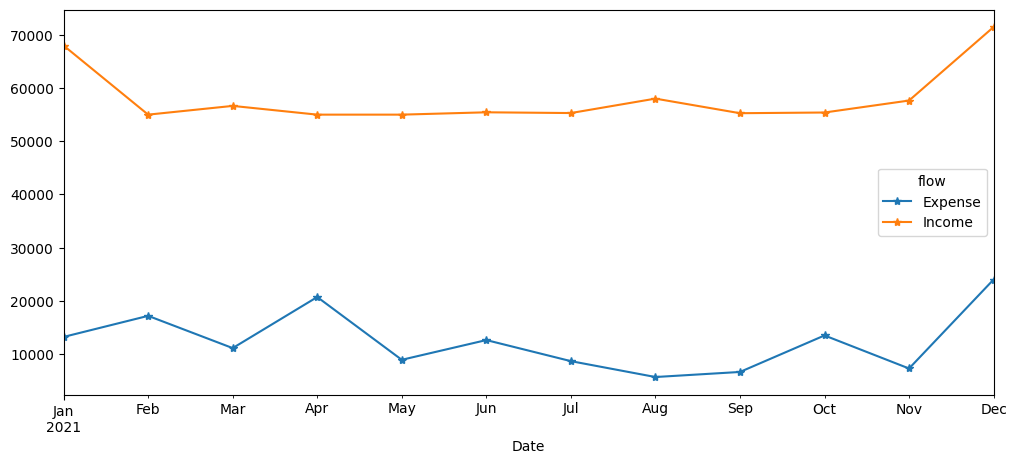

In [67]:
df_ts = fin_df.groupby([fin_df['Date'], 'flow'])['transaction_amount'].sum().unstack(fill_value = 0)

df_ts.index = pd.to_datetime(df_ts.index)
df_ts  = df_ts.resample('ME').sum()

df_ts.plot(kind = 'line', marker = '*', figsize = (12,5))


#### Let us see the division of expenses acrros the whole year.

<Axes: >

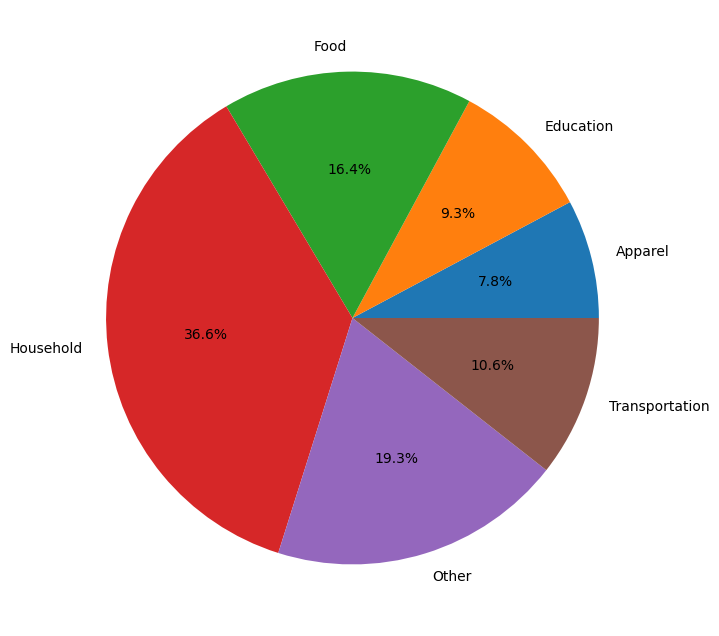

In [68]:
expense.groupby('Category')['transaction_amount'].sum().plot(kind = 'pie', autopct = '%1.1f%%', figsize = (8,8))


While Food dominates in transaction frequencym accounting for over 50% of all expense enteries, Household is the largest expenditure by value at 36.6%, driven by fewer but significantly higher value transactions like rent and deposits. The highlights a key distinction between spending frequency and spending impact.


This phenomenon even has a name in behavioural finance  "denomination effect"  small frequent purchases feel insignificant even when they add up.

<Axes: >

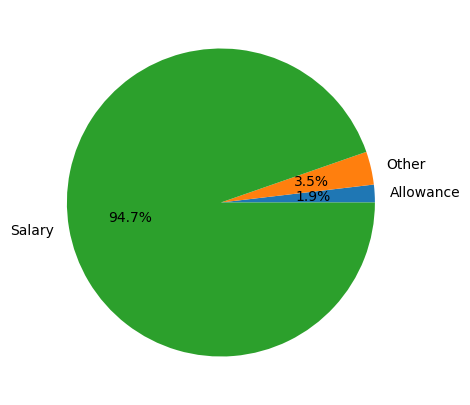

In [69]:
income.groupby('Category')['transaction_amount'].sum().plot(kind = 'pie', autopct = '%1.1f%%', figsize = (12,5))

In [70]:
import plotly.express  as px

fig = px.pie(expense.groupby('Category')['transaction_amount'].sum().reset_index(),
values = 'transaction_amount',
names = 'Category',
title = 'Expense by category')

fig.show()

Main income source is Salary

### 2. Time based spending behaviour

In [71]:
expense.dtypes          # all columns and their types

Date                   object
Time                   object
Category                  str
Sub category              str
flow                      str
transaction_amount    float64
dtype: object

(array([0, 1, 2, 3]),
 [Text(0, 0, '1. Morning'),
  Text(1, 0, '2. Afternoon'),
  Text(2, 0, '3.Evening'),
  Text(3, 0, '4. Night')])

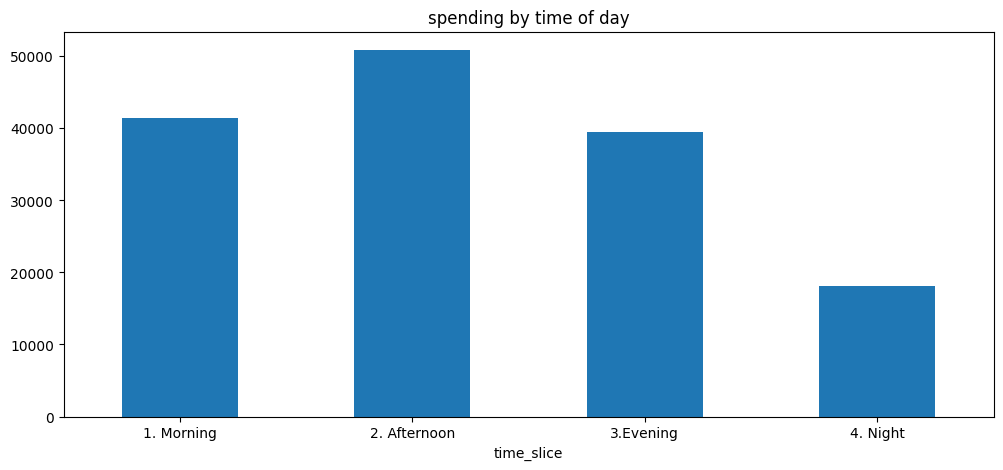

In [72]:
from matplotlib.pyplot import xticks


expense['Time'] = pd.to_datetime(expense['Time'], format = '%H:%M:%S')
expense['Date'] = pd.to_datetime(expense['Date'], format = '%Y-%m-%d')


expense['hour'] = expense['Time'].dt.hour

def time_slice(hour):
    if 6 <= hour <= 11: return '1. Morning'
    elif 12 <= hour <= 16 : return '2. Afternoon'
    elif 17 <= hour <= 21: return '3.Evening'
    else: return '4. Night'



expense['time_slice'] = expense['hour'].apply(time_slice)
expense.groupby('time_slice')['transaction_amount'].sum().plot(
    kind = 'bar',
    figsize=(12, 5),
    title = 'spending by time of day'
)
plt.xticks(rotation = 0)


1. Common pattern behaviour is going out after the office, expected night expenditure to be the most, but it turned out to be the least

exploring further, it it that afteroon is more inflated, that huge transaction, such as rent, bill paymenets, etc, or the small number of transactions

In [73]:
round(expense.groupby('time_slice')['transaction_amount'].agg(['sum','count','mean']),2)

,sum,count,mean
time_slice,,,
1. Morning,41427.15,34,1218.45
2. Afternoon,50861.75,71,716.36
3.Evening,39416.38,64,615.88
4. Night,18148.00,13,1396.00


Afternoon spending is driven by frequency — many small habitual purchases. Night spending is driven by value — rare but significant transactions.

In [74]:
expense.groupby(['Category'])['transaction_amount'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending = True)

,sum,count,mean
Category,,,
Apparel,11674.72,8,1459.340000
Education,14000.00,1,14000.000000
Transportation,15873.80,26,610.530769
Food,24607.76,114,215.857544
Other,28887.00,21,1375.571429
Household,54810.00,12,4567.500000


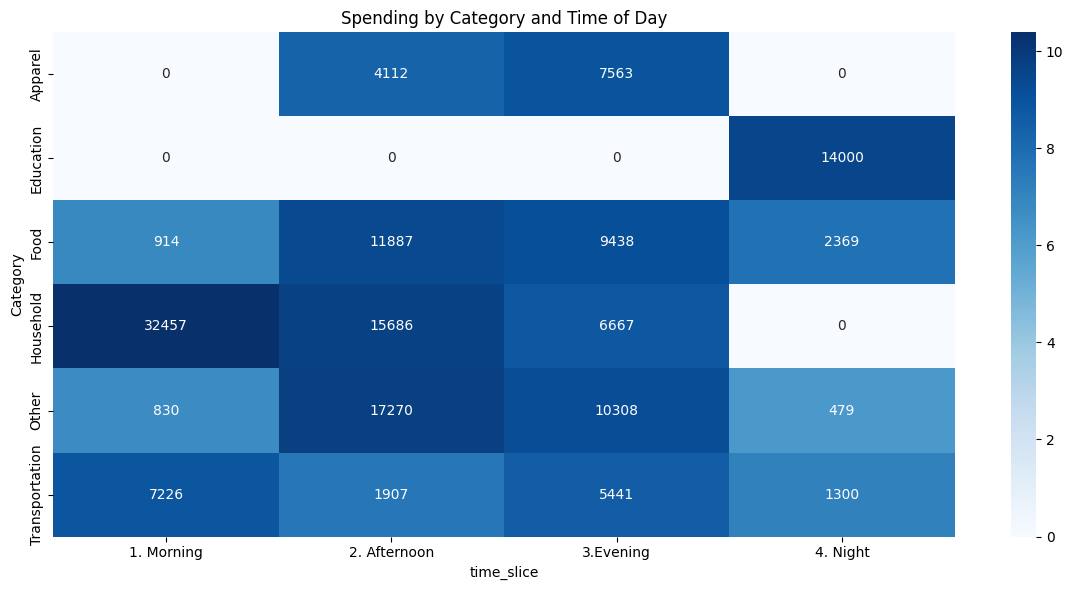

In [75]:
# display is the form of heatmap

pivot = expense.pivot_table(
    index = 'Category',
    columns = 'time_slice',
    values = 'transaction_amount',
    aggfunc = 'sum',
    fill_value = 0
)


import numpy as np

pivot_log = np.log1p(pivot)  # log(1 + value) handles zeros

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_log, annot=pivot, fmt='.0f', cmap='Blues')
plt.title('Spending by Category and Time of Day')
plt.tight_layout()
plt.show()

# "Where does the money actually go, and does the spending behaviour reflect good financial health?"

Business case has been set. 

## Business Questions

1. Where is money going and which categories have room to cut?
2. Is the savings rate healthy and consistent across the year?
3. How stable is income and are there sources beyond salary?

<Axes: title={'center': 'Total spending by category'}, ylabel='Category'>

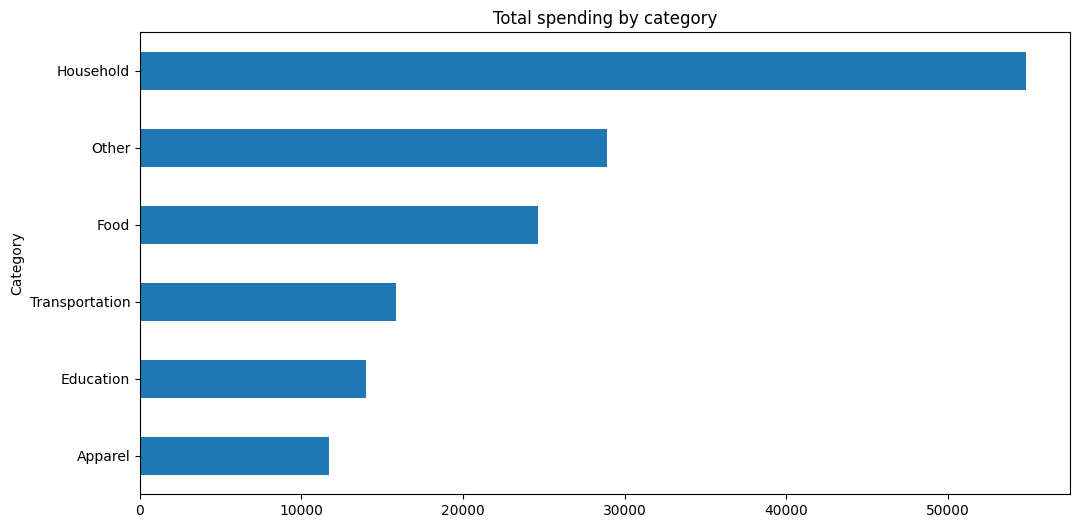

In [76]:
expense.groupby('Category')['transaction_amount'].sum().sort_values().plot(
    kind ='barh',
    figsize =(12,6),
    title = 'Total spending by category'
)

household contributes the most part of the expenditure.

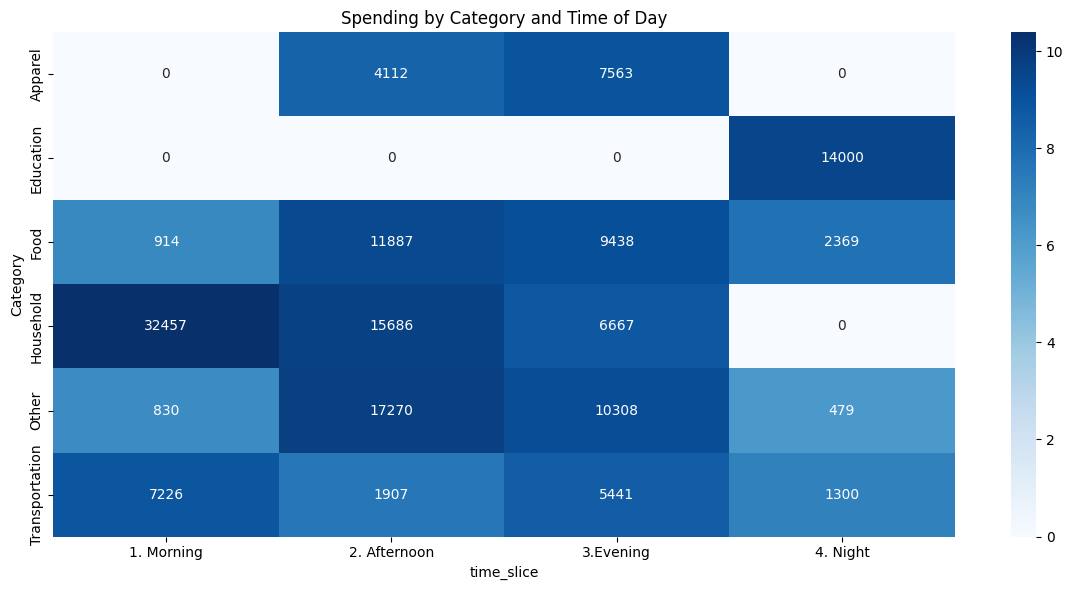

In [77]:
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_log, annot=pivot, fmt='.0f', cmap='Blues')
plt.title('Spending by Category and Time of Day')
plt.tight_layout()
plt.show()


| Category | Peak Time | Behaviour |
|---|---|---|
| Household | Morning | Rent and fixed costs paid early in the day — planned, committed expense. Largest drain at ₹54,810 |
| Food | Afternoon | Lunch driven spending — habitual daily expense at ₹24,607. High frequency, moderate value |
| Other | Afternoon | Catch-all daytime spending at ₹28,887 — needs deeper sub-category investigation |
| Transportation | Morning | Commute driven — morning travel to work dominates at ₹15,874 |
| Apparel | Evening | Post work shopping behaviour — impulsive or leisure driven at ₹11,675 |
| Education | Night | Single one-time payment of ₹14,000 — not a recurring pattern |

### Key Takeaway
Household and Other together account for nearly 56% of total expenses. Food is habitual but moderate. Apparel and Transportation are the most controllable categories with clear behavioural triggers, commute and post-work shopping.

<Axes: xlabel='day_of_week', ylabel='Category'>

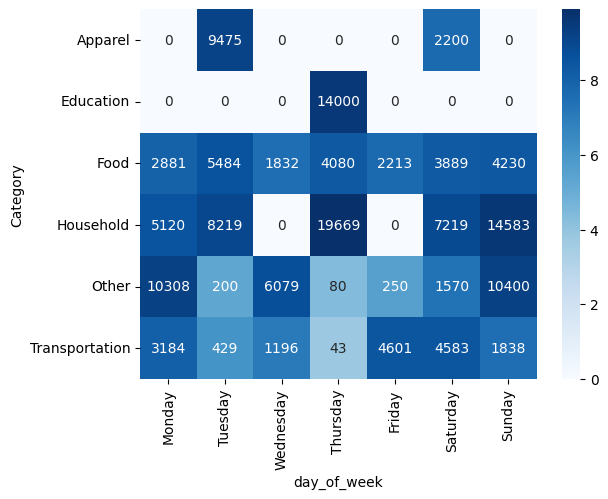

In [78]:
expense['day_of_week'] = pd.to_datetime(expense['Date']).dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot_day = expense.pivot_table(
    index='Category',
    columns='day_of_week',
    values='transaction_amount',
    aggfunc='sum',
    fill_value=0
)[day_order]

import numpy as np
sns.heatmap(np.log1p(pivot_day), annot=pivot_day, fmt='.0f', cmap='Blues')

## Day of Week Spending Pattern — Key Observations

| Observation | Insight |
|---|---|
| Household Thursday ₹19,669 | Likely rent payment day, consistent fixed cost |
| Apparel Tuesday ₹9,475 | Mid week online shopping behaviour |
| Education Thursday ₹14,000 | One time fee paid on a Thursday |
| Other Monday ₹10,308 | Week start miscellaneous spending |
| Food is spread across all days | Truly habitual, no single spike day |
| Transportation Friday ₹4,601 and Saturday ₹4,583 | Weekend travel pattern |

In [79]:
for category in ['Household', 'Apparel', 'Food', 'Other']:
    print(f"\n--- {category} ---")
    print(expense[expense['Category'] == category]['Sub category'].value_counts())


--- Household ---
Sub category
Stuffs      7
Bean bag    3
Rent        1
Mirror      1
Name: count, dtype: int64

--- Apparel ---
Sub category
Badminton           1
Games               1
Hoodie for gobi     1
Earphone            1
Spiderman           1
Beer                1
Bharath birthday    1
Books               1
Name: count, dtype: int64

--- Food ---
Sub category
Lunch with company        11
Snacks                     9
Lunch                      8
Milk with bharath          7
Dinner                     6
                          ..
Corn                       1
Coconut water with stu     1
Coffee and thattai         1
Horlicks + kolakattai      1
To barath                  1
Name: count, Length: 67, dtype: int64

--- Other ---
Sub category
To vicky                                       3
To kumara                                      2
To vishnu                                      1
Sent to barath                                 1
Tablet to gowdham                             

Category has been misguided

In [80]:
def classify_sub(row):
    sub = row['Sub category'].lower()
    cat = row['Category']

    if cat == 'Other':
        return 'Lending'
    elif cat == 'Apparel':
        return 'Lifestyle Purchase'
    elif 'lunch' in sub or 'dinner' in sub:
        return 'Social Dining'
    elif 'snack' in sub or 'milk' in sub or 'coffee' in sub:
        return 'Daily Habit'
    else:
        return 'Other'

expense['sub_group'] = expense.apply(classify_sub, axis = 1)

In [81]:
print("--- Household ---")
print(expense[expense['Category'] == 'Household'].groupby('day_of_week')['transaction_amount'].sum().reindex(day_order))

print("\n--- Apparel ---")
print(expense[expense['Category'] == 'Apparel'].groupby('day_of_week')['transaction_amount'].sum().reindex(day_order)[['Tuesday', 'Saturday']])

print("\n--- Food ---")
print(expense[expense['Category'] == 'Food'].groupby('sub_group')['transaction_amount'].sum().sort_values(ascending=False))

print("\n--- Other ---")
print(expense[expense['Category'] == 'Other'].groupby('day_of_week')['transaction_amount'].sum().reindex(day_order)[['Monday', 'Sunday']])

--- Household ---
day_of_week
Monday        5120.0
Tuesday       8219.0
Wednesday        NaN
Thursday     19669.0
Friday           NaN
Saturday      7219.0
Sunday       14583.0
Name: transaction_amount, dtype: float64

--- Apparel ---
day_of_week
Tuesday     9474.72
Saturday    2200.00
Name: transaction_amount, dtype: float64

--- Food ---
sub_group
Social Dining    12506.76
Other             6410.00
Daily Habit       5691.00
Name: transaction_amount, dtype: float64

--- Other ---
day_of_week
Monday    10308.0
Sunday    10400.0
Name: transaction_amount, dtype: float64


## Sub-Category Deep Dive — Question 1

### Household
No consistent rent payment day. High value transactions scattered across the week — confirms this is lifestyle and one-off purchases, not fixed rent. Most cuttable than the category name suggests.

### Apparel
Tuesday ₹9,475 vs Saturday ₹2,200. Tuesday is likely online shopping — mid week, work hours, browsing during breaks. Saturday is casual in-person purchase. The Tuesday spike is the impulsive behaviour to watch.

### Food
| Sub Group | Amount |
|---|---|
| Social Dining | ₹12,507 |
| Other | ₹6,410 |
| Daily Habit | ₹5,691 |

Social dining is the biggest food expense — eating out with friends dominates over daily habits. This is the most cuttable food behaviour. Daily habits like snacks and milk are actually quite controlled.

### Other
Monday ₹10,308 and Sunday ₹10,400 — almost equal. Suggests a weekend to weekday lending pattern. Money given to friends on Sunday and Monday consistently. Not consumption — a social lending habit.

### Overall Insight
The most cuttable expenses are Social Dining (Food), Tuesday online shopping (Apparel), and peer lending (Other) which may or may not be returned. Household is not fixed rent but lifestyle purchases, also reviewable.

# "Is the savings rate healthy and consistent across the year?"



In [82]:
income.head()

,Date,Time,Category,Sub category,flow,transaction_amount
0,2021-01-01,21:45:00,Allowance,From dad,Income,8000.0
2,2021-01-03,18:21:00,Other,From dad,Income,500.0
9,2021-01-14,16:56:00,Other,Gundan + prasanna,Income,340.0
10,2021-01-15,21:16:00,Other,From dad,Income,1500.0
17,2021-01-21,11:47:00,Other,From vicky,Income,200.0


In [83]:
fin_df.dtypes

Date                   object
Time                   object
Category                  str
Sub category              str
flow                      str
transaction_amount    float64
dtype: object

In [84]:
# create a dataframe, to get monly saving rate

from calendar import month


fin_df['Date'] = pd.to_datetime(fin_df['Date'])
monthly = fin_df.groupby([pd.Grouper(key = 'Date', freq = 'ME'), 'flow'])['transaction_amount'].sum().unstack(fill_value=0)

monthly.index = monthly.index.strftime('%b')

monthly['savings'] = monthly['Income'] - monthly['Expense']
monthly['saving_rate'] = round((monthly['savings']/ monthly['Income'] * 100), 2)

In [85]:
monthly.head()

flow,Expense,Income,savings,saving_rate
Date,,,,
Jan,13244.15,67975.0,54730.85,80.52
Feb,17200.95,55000.0,37799.05,68.73
Mar,11145.00,56641.0,45496.00,80.32
Apr,20739.00,55000.0,34261.00,62.29
May,8945.72,55000.0,46054.28,83.74


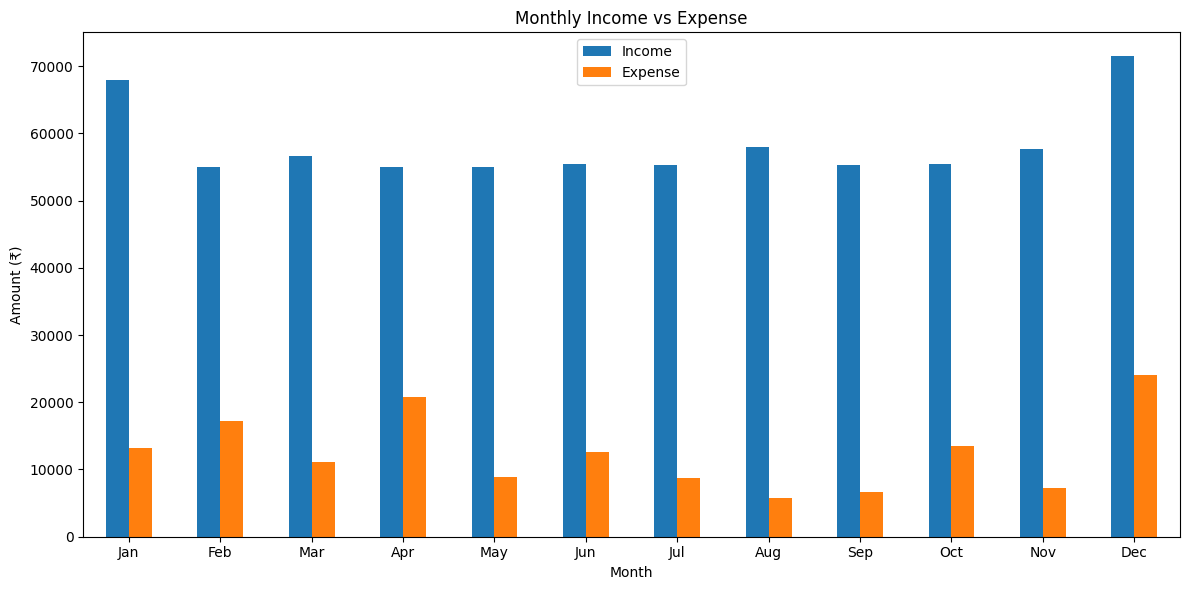

In [86]:
monthly[['Income','Expense']].plot(
    kind = 'bar',
    figsize = (12, 6),
    title = 'Monthly Income vs Expense'
)


plt.xticks(rotation = 0)
plt.legend(title ='', loc = 'best')
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.tight_layout()
plt.show()

Overall conclusion:
Income consistently exceeds expense every single month — the financial position is healthy throughout 2021.

Three behavioural patterns visible:

Mid year (Aug-Sep) is the most disciplined period, expenses drop significantly
Year end (Dec) shows splurge behaviour, both income and expense spike together
Apr spike needs investigation,  was it Education fee (₹14K) or household?

Income to expense ratio is healthy across all 12 months with no deficit month. However spending is not consisteny, April and December show notable spikes suggesting event driven expenditure rather than controlled budgeting

Average Annual Savings Rate: 78.71%


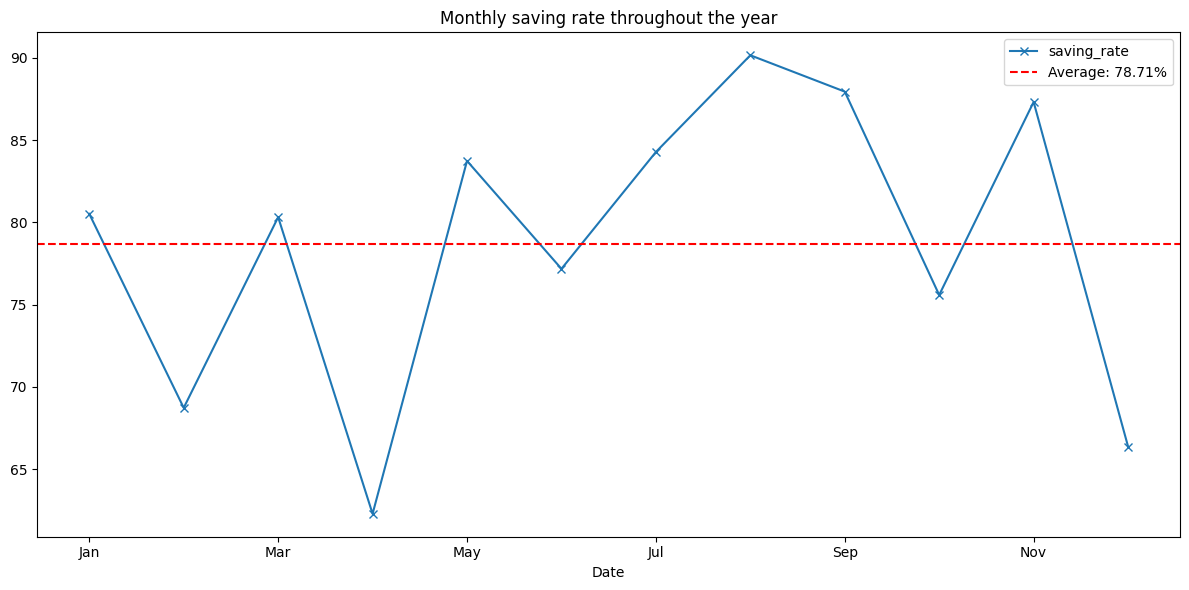

In [87]:
monthly['saving_rate'].plot(
    kind = 'line',
    marker = 'x',
    figsize = (12,6),
    title = 'Monthly saving rate throughout the year'

)
avg_savings_rate = monthly['saving_rate'].mean().round(2)
print(f"Average Annual Savings Rate: {avg_savings_rate}%")

plt.axhline(y = monthly['saving_rate'].mean(), color = 'red', linestyle ='--', label = f'Average: {avg_savings_rate}%')
plt.legend()
plt.tight_layout()
plt.show()

It shows exceptional saving, but this savings rate may be inflated because major fixed costs like rent may not be fully captured in this tracker, as we saw Household only had 1 rent entry. The true savings rate could be lower.

Question 3 - How stable is income and are there sources beyond salary?

In [88]:
fin_df[(fin_df['flow'] == 'Income') & (fin_df['Category'] == 'Salary')]

,Date,Time,Category,Sub category,flow,transaction_amount
28,2021-01-27,13:38:00,Salary,office,Income,55000.0
64,2021-02-28,11:45:00,Salary,office,Income,55000.0
74,2021-03-21,21:12:00,Salary,office,Income,55000.0
85,2021-04-21,22:10:00,Salary,office,Income,55000.0
97,2021-05-21,20:23:00,Salary,office,Income,55000.0
112,2021-06-22,16:41:00,Salary,office,Income,55000.0
120,2021-07-26,17:37:00,Salary,office,Income,55000.0
125,2021-08-02,10:37:00,Salary,office,Income,55000.0
140,2021-09-24,20:17:00,Salary,office,Income,55000.0
144,2021-10-01,21:11:00,Salary,office,Income,55140.0


Salary is constant

In [89]:
income['Date'] = pd.to_datetime(income['Date'])
income_salary = income[income['Category'] == 'Salary'].groupby([pd.Grouper(key = 'Date', freq = 'ME')])['transaction_amount'].sum()
income_total = income.groupby([pd.Grouper(key = 'Date', freq = 'ME')])['transaction_amount'].sum()

income_non_salary = -income_salary + income_total
income_non_salary.index = income_non_salary.index.strftime('%B')

income_non_salary

Date
January      12975.0
February         0.0
March         1641.0
April            0.0
May              0.0
June           440.0
July           300.0
August        3010.0
September      270.0
October        261.0
November      2410.0
December     15930.0
Name: transaction_amount, dtype: float64

other income source in Jaannuary and December is quite high. let us inspect that.

In [90]:
#create a heat map


print(income.Category.nunique(), income.Category.unique())

3 <StringArray>
['Allowance', 'Other', 'Salary']
Length: 3, dtype: str


In [91]:
income_allowance = income[income['Category'] == 'Allowance'].groupby([pd.Grouper(key = 'Date', freq = 'ME')])['transaction_amount'].sum()
income_allowance.index = income_allowance.index.strftime('%b')

income_allowance


Date
Jan    8000.0
Feb       0.0
Mar       0.0
Apr       0.0
May       0.0
Jun       0.0
Jul       0.0
Aug       0.0
Sep       0.0
Oct       0.0
Nov       0.0
Dec    5000.0
Name: transaction_amount, dtype: float64

This debugs, let us explore sub categories

In [92]:
allowance_subcats = income.loc[
    income['Category'] == 'Allowance',
    'Sub category'
]

print(
    allowance_subcats.nunique(),
    allowance_subcats.unique()
)

1 <StringArray>
['From dad']
Length: 1, dtype: str


got money from other peoplee, mostly of festive money?


In [93]:
#now explore other

income_category = income[income['Category'] == 'Other'].groupby([pd.Grouper(key = 'Date', freq = 'ME')])['transaction_amount'].sum()
income_category.index = income_category.index.strftime('%b')
print(
    income[income['Category'] == 'Other']['Sub category'].nunique(),
    income[income['Category'] == 'Other']['Sub category'].unique()
)

15 <StringArray>
[              'From dad',      'Gundan + prasanna',             'From vicky',
  'Vishnu 100 gowdham 25',               'From abi',            'From shakur',
            'From barath', 'From barath and shakur',           'From gowdham',
            'From Deepak',                 'Kumara',           'From ganesan',
        'Siva + 100 cash',            'From kumara',           'Lended money']
Length: 15, dtype: str


| Finding | Insight |
|---|---|
| Salary is perfectly stable | ₹55,000 every single month without fail |
| Salary grew slightly | Oct ₹55,140 → Nov ₹55,240 → Dec ₹55,530 — small increment |
| Non-salary income exists but irregular | Only 7 out of 12 months had any non-salary income |
| Non-salary sources are informal | Family support and peer lending returns — not investment or side income |
| Jan and Dec spikes are festive | Diwali/New Year family transfers explain the bumps |

### Final Answer
Income is highly stable, driven entirely by a fixed monthly salary with minor increments in Q4. 

## Overall Conclusion — Behavioural Finance Analysis 2021

**Spending** — Household and Food dominate expenses. Most spending is lifestyle 
and social — not fixed committed costs. Highest opportunity to cut: social dining, 
Tuesday online shopping, and peer lending.

**Savings** — Average savings rate of 78.71% is exceptional. No deficit month. 
However spending is event driven, not consistently budgeted.

**Income** — Perfectly stable salary of ₹55,000/month with slight Q4 increment. 
No side income, investments, or passive income streams recorded.

**Bottom Line** — Financially healthy but over-reliant on a single income source. 
High savings rate is not being put to work.


## 3 Behavioural Insights

**1. Social Spending Disguised as Food Expense**
The largest food expense is Social Dining — eating out with friends dominates 
over daily meals. People underestimate food spending because individual transactions 
feel small and habitual, masking the cumulative social cost.

**2. Payday Illusion — High Income Does Not Mean High Awareness**
Despite a 78.71% savings rate, spending spikes in April and December suggest 
event driven splurging rather than conscious budgeting. People spend more when 
they feel financially secure, not because they planned to.

**3. Informal Lending as Hidden Expense**
A significant portion of Other category is money lent to friends — recorded as 
expense but mentally treated as temporary. This creates a blind spot in personal 
finance tracking where real cash outflow is underestimated.

<Axes: title={'center': 'transaction_amount'}, xlabel='Category'>

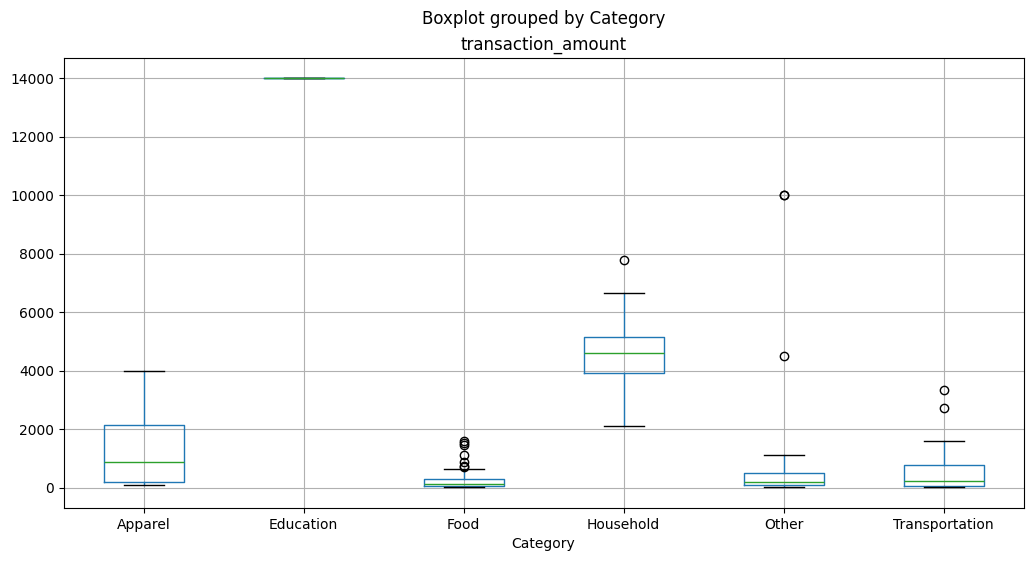

In [94]:
expense.boxplot(column='transaction_amount', by='Category', figsize=(12,6))

In [95]:
Q1 = expense['transaction_amount'].quantile(0.25)
Q3 = expense['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = expense[expense['transaction_amount'] > Q3 + 1.5 * IQR]
print(outliers)

          Date                Time        Category           Sub category  \
3   2021-01-03 1900-01-01 18:22:00       Household                 Stuffs   
6   2021-01-12 1900-01-01 14:00:00            Food     Lunch with company   
12  2021-01-17 1900-01-01 18:31:00            Food              Eve snack   
30  2021-01-27 1900-01-01 13:41:00           Other              To vishnu   
48  2021-02-19 1900-01-01 06:18:00  Transportation              To egmore   
51  2021-02-19 1900-01-01 21:35:00  Transportation             Bus ticket   
56  2021-02-21 1900-01-01 15:40:00       Household                 Stuffs   
57  2021-02-21 1900-01-01 22:15:00  Transportation  It better be worth it   
59  2021-02-23 1900-01-01 17:35:00         Apparel        Hoodie for gobi   
73  2021-03-15 1900-01-01 21:17:00  Transportation       Bus to Bangalore   
75  2021-03-22 1900-01-01 06:33:00       Household                 Stuffs   
76  2021-03-23 1900-01-01 12:38:00         Apparel               Earphone   

In [96]:
expense.nlargest(10, 'transaction_amount')

,Date,Time,Category,Sub category,flow,transaction_amount,hour,time_slice,day_of_week,sub_group
81,2021-04-01,1900-01-01 22:11:00,Education,Arrear and reval fee,Expense,14000.0,22,4. Night,Thursday,Other
150,2021-10-18,1900-01-01 21:01:00,Other,To kumara,Expense,10000.0,21,3.Evening,Monday,Lending
197,2021-12-19,1900-01-01 15:51:00,Other,To siva,Expense,10000.0,15,2. Afternoon,Sunday,Lending
182,2021-12-02,1900-01-01 16:04:00,Household,Mirror,Expense,7770.0,16,2. Afternoon,Thursday,Other
3,2021-01-03,1900-01-01 18:22:00,Household,Stuffs,Expense,6667.0,18,3.Evening,Sunday,Other
86,2021-04-22,1900-01-01 06:33:00,Household,Stuffs,Expense,5180.0,6,1. Morning,Thursday,Other
75,2021-03-22,1900-01-01 06:33:00,Household,Stuffs,Expense,5120.0,6,1. Morning,Monday,Other
98,2021-05-22,1900-01-01 06:33:00,Household,Stuffs,Expense,5120.0,6,1. Morning,Saturday,Other
116,2021-07-22,1900-01-01 06:33:00,Household,Stuffs,Expense,4620.0,6,1. Morning,Thursday,Other
122,2021-08-01,1900-01-01 13:38:00,Household,Rent,Expense,4580.0,13,2. Afternoon,Sunday,Other


Yes — from the boxplot and table, clear outliers are:

---

**Definite outliers:**

| Amount | Category | Sub category | Why it is an outlier |
|---|---|---|---|
| ₹14,000 | Education | Arrear and reval fee | Only transaction, far above all others |
| ₹10,000 | Other | To kumara | Double the normal Other transactions |
| ₹10,000 | Other | To siva | Same — large peer lending |
| ₹7,770 | Household | Mirror | Single large purchase, well above box |
| ₹6,667 | Household | Stuffs | January anomaly |

---

**Borderline outliers:**

| Amount | Category | Why |
|---|---|---|
| ₹5,120 | Household | Appears multiple times — pattern, not anomaly |
| ₹3,999 | Apparel | Hoodie — large but within category range |
| ₹3,325 | Transportation | Train to Bangalore — long distance, not habitual |

---

**Key insight:**

> Most outliers are **explainable and one-time**, exam fee, peer lending, long distance travel. They are not signs of erratic behaviour but rather **event driven spending.** This actually reinforces that day-to-day spending is disciplined.

That is a strong concluding insight for your outlier section. Want it in markdown?